<a href="https://colab.research.google.com/github/eduardodpms/UnB_Notebooks/blob/main/24.2%20TEMA/Trabalho%202/TEMA_2024_2_proj2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabalho 2 - Tópicos Especiais em Matemática Aplicada

Faculdade de Ciências e Tecnologias em Engenharia (FCTE) - 2024/2

Docente: Vinicius de Carvalho Rispoli

Grupo:
*   Eduardo de Pina Moreira Santos - 231034494
*   João Maurício Pilla Nascimento - 231011533

  Neste trabalho, buscamos utilizar os modelos Encoder-Decoder do tipo LSTM, LSTM com Atenção de Bahdanau e com Transformadores para traduzir frases simples do Francês para o Portugês, a fim de que possamos comparar seus desempenhos.


---



In [ ]:
# Importações necessárias
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding, LSTM, Dense, Input, Concatenate, MultiHeadAttention, LayerNormalization, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.utils import to_categorical

In [ ]:
# Criando Subplot que será utilizado no projeto
plt.figure(figsize=(18, 5))
plt.ioff()  # Desativa o modo interativo

<Figure size 1800x500 with 0 Axes>

In [ ]:
# Número de Épocas que será utilizado nos treinamentos
epocas = 20

In [ ]:
# Frases para teste
frase_p = "j'adore voir des chats" # "eu adoro ver gatos"
frase_g = "au ver qui a rongé en premier la chair froide de mon cadavre" # "ao verme que primeiro roeu as frias carnes do meu cadáver"

# Etapas Padrão para modelos Encoder-Decoder LSTM

É importante ressaltar que os três modelos de Encoder-Decoder que serão trabalhados possuem a mesma base, que são as LSTM's (Long Short-Term Memory). Por isso, suas etapas base, neste trabalho, são as mesmas. De forma resumida:


*   Encoder: Processa a sequência de entrada (uma frase, por exemplo) e a converte em uma representação compacta (vetor de contexto). Aqui, o LSTM captura as dependências temporais e relações de longo prazo na sequência.
*   Decoder: Gera a sequência de saída (uma tradução, por exemplo). Ela recebe a representação compacta do encoder e, com base nela, gera a saída, usando a LSTM.
*   LSTM: Um tipo de Rede Neura Recorrente capaz de aprender e reter dependências de longo prazo, mitigando problemas relacionados ao cálculo do gradiente.




In [ ]:
# Carregando o dataset TED Talks (Francês -> Português)
data, metadata = tfds.load("ted_hrlr_translate/fr_to_pt", with_info=True, as_supervised=True)
train_data, val_data, test_data = data['train'], data['validation'], data['test']

In [ ]:
# Função para pré-processar os dados, convertendo os dados do TF para listas de frases em francês e português
def preprocess_data(dataset):
    french_sentences = []
    portuguese_sentences = []
    for fr, pt in dataset:
        french_sentences.append(fr.numpy().decode('utf-8')) # Converte bytes para string
        portuguese_sentences.append(pt.numpy().decode('utf-8'))
    return french_sentences, portuguese_sentences

In [ ]:
# Pré-processamento dos dados, extraindo frases de cada conjunto
train_fr, train_pt = preprocess_data(train_data)
val_fr, val_pt = preprocess_data(val_data)
test_fr, test_pt = preprocess_data(test_data)

In [ ]:
# Definição do tamanho dos conjuntos de dados
train_size = 52_000
val_size = 1_200
test_size = 1_800

# Reduzindo os conjuntos para os tamanhos definidos
train_fr = train_fr[:train_size]
train_pt = train_pt[:train_size]
val_fr = val_fr[:val_size]
val_pt = val_pt[:val_size]
test_fr = test_fr[:test_size]
test_pt = test_pt[:test_size]

In [ ]:
# Função para tokenizar os textos
def tokenize_text(sentences):
    sentences = ['<start> ' + sentence + ' <end>' for sentence in sentences] # Adiciona tokens de início e fim
    tokenizer = Tokenizer(filters='') # Remove filtros padrão
    tokenizer.fit_on_texts(sentences) # Ajusta o tokenizer com base no vocabulário
    return tokenizer

In [ ]:
# Tokenizando as frases em francês e português
fr_tokenizer = tokenize_text(train_fr)
pt_tokenizer = tokenize_text(train_pt)

# Convertendo os textos tokenizados em sequências numéricas
train_fr_seq = fr_tokenizer.texts_to_sequences(train_fr)
train_pt_seq = pt_tokenizer.texts_to_sequences(train_pt)
val_fr_seq = fr_tokenizer.texts_to_sequences(val_fr)
val_pt_seq = pt_tokenizer.texts_to_sequences(val_pt)

In [ ]:
# Definição do comprimento máximo das sequências
max_length_fr = 50
max_length_pt = 50

# Padronizando o tamanho das sequências com padding
train_fr_seq = pad_sequences(train_fr_seq, maxlen=max_length_fr, padding='post', truncating='post')
train_pt_seq = pad_sequences(train_pt_seq, maxlen=max_length_pt, padding='post', truncating='post')
val_fr_seq = pad_sequences(val_fr_seq, maxlen=max_length_fr, padding='post', truncating='post')
val_pt_seq = pad_sequences(val_pt_seq, maxlen=max_length_pt, padding='post', truncating='post')

In [ ]:
# Armazena as frases traduzidas para cada modelo
traducoes = [[], [], []]

In [ ]:
# Traduz uma frase do francês para o português
def translate(frase, model, fr_tokenizer, pt_tokenizer, max_length_fr, max_length_pt):

    fr_seq = fr_tokenizer.texts_to_sequences([frase])  # Converte a frase em números
    fr_seq = pad_sequences(fr_seq, maxlen=max_length_fr, padding='post', truncating='post')  # Padroniza o tamanho da sequência

    # Cria o input do decoder (sequência de saída em português inicializada com o token inicial)
    decoder_input = np.zeros((1, max_length_pt))  # Um batch com um exemplo
    decoder_input[0, 0] = pt_tokenizer.word_index['<start>']  # A primeira palavra do decoder é o token <start>

    translation = []
    for i in range(max_length_pt - 1):  # Limitar o número de palavras na tradução
        predictions = model([fr_seq, decoder_input])  # A entrada para o modelo são as frases em francês e a sequência parcial do decoder

        predicted_token = np.argmax(predictions[0, i, :])  # Pega o índice da palavra com maior probabilidade

        if predicted_token == pt_tokenizer.word_index['<end>']:   # Se o token de parada (<end>) for gerado, paramos a tradução
            break

        # Adiciona o token à tradução e atualiza a entrada do decoder
        predicted_word = pt_tokenizer.index_word.get(predicted_token, '')  # Converte o índice de volta para palavra
        translation.append(predicted_word)

        decoder_input[0, i + 1] = predicted_token   # Atualiza a entrada do decoder com o token previsto

    return ' '.join(translation)

# Encoder-Decoder com LTSM



---


Uma rede Encoder-Decoder com LSTM (Long Short-Term Memory) é um modelo de aprendizado profundo usado para tarefas sequenciais, como tradução automática e resumo de texto. Sua principal aplicação é para sequências curtas de caracteres, pois sofre com perda de informação ao usar um único vetor para representar toda a entrada. É a base para os próximos modelos, como o com Atenção e o com Transformers.


---



In [ ]:
# Definição do modelo Encoder-Decoder com LSTM
class EncoderDecoderModel(Model):
    def __init__(self, vocab_size_fr, vocab_size_pt, embedding_dim, lstm_units):
        super(EncoderDecoderModel, self).__init__()
        self.embedding_fr = Embedding(vocab_size_fr, embedding_dim)   # Camada de embedding para o encoder (francês)
        self.encoder_lstm = LSTM(lstm_units, return_state=True)   # Camada LSTM do encoder, retornando os estados oculto e de célula
        self.embedding_pt = Embedding(vocab_size_pt, embedding_dim)   # Camada de embedding para o decoder (português)
        self.decoder_lstm = LSTM(lstm_units, return_sequences=True, return_state=True)    # Camada LSTM do decoder, que retorna sequência e estados
        self.dense = Dense(vocab_size_pt, activation='softmax')   # Camada densa para prever a próxima palavra na saída

    def call(self, inputs):
        fr_input, pt_input = inputs   # Entrada do encoder e do decoder
        fr_emb = self.embedding_fr(fr_input)    # Passa os inputs franceses pela camada de embedding
        _, state_h, state_c = self.encoder_lstm(fr_emb)   # Obtém os estados do encoder LSTM
        pt_emb = self.embedding_pt(pt_input)    # Passa os inputs portugueses pela camada de embedding
        decoder_output, _, _ = self.decoder_lstm(pt_emb, initial_state=[state_h, state_c])    # Alimenta o decoder LSTM com os estados do encoder
        output = self.dense(decoder_output)   # Gera a saída com distribuição de probabilidade sobre o vocabulário
        return output

In [ ]:
# Definição de hiperparâmetros do modelo
embedding_dim = 256
lstm_units = 256
vocab_size_fr = len(fr_tokenizer.word_index) + 1
vocab_size_pt = len(pt_tokenizer.word_index) + 1

In [ ]:
# Criando e compilando o modelo
model = EncoderDecoderModel(vocab_size_fr, vocab_size_pt, embedding_dim, lstm_units)
model.compile(optimizer=AdamW(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# Ajustando os dados de saída para prever a próxima palavra
train_target = pad_sequences([seq[1:] for seq in train_pt_seq], maxlen=max_length_pt, padding='post')
val_target = pad_sequences([seq[1:] for seq in val_pt_seq], maxlen=max_length_pt, padding='post')

In [ ]:
# Treinamento do modelo
history_lstm = model.fit(
    [train_fr_seq, train_pt_seq], train_target,
    batch_size=64,
    epochs=epocas,
    validation_data=([val_fr_seq, val_pt_seq], val_target)
)

Epoch 1/20
686/686 ━━━━━━━━━━━━━━━━━━━━ 140s 200ms/step - accuracy: 0.6869 - loss: 3.0997 - val_accuracy: 0.7412 - val_loss: 1.8109
Epoch 2/20
686/686 ━━━━━━━━━━━━━━━━━━━━ 141s 198ms/step - accuracy: 0.7292 - loss: 1.9217 - val_accuracy: 0.7538 - val_loss: 1.6769
Epoch 3/20
686/686 ━━━━━━━━━━━━━━━━━━━━ 142s 199ms/step - accuracy: 0.7418 - loss: 1.7541 - val_accuracy: 0.7596 - val_loss: 1.5963
Epoch 4/20
686/686 ━━━━━━━━━━━━━━━━━━━━ 143s 200ms/step - accuracy: 0.7489 - loss: 1.6484 - val_accuracy: 0.7626 - val_loss: 1.5545
Epoch 5/20
686/686 ━━━━━━━━━━━━━━━━━━━━ 142s 200ms/step - accuracy: 0.7557 - loss: 1.5513 - val_accuracy: 0.7647 - val_loss: 1.5298
Epoch 6/20
686/686 ━━━━━━━━━━━━━━━━━━━━ 142s 201ms/step - accuracy: 0.7618 - loss: 1.4712 - val_accuracy: 0.7673 - val_loss: 1.5125
Epoch 7/20
686/686 ━━━━━━━━━━━━━━━━━━━━ 142s 201ms/step - accuracy: 0.7665 - loss: 1.4010 - val_accuracy: 0.7689 - val_loss: 1.5029
Epoch 8/20
686/686 ━━━━━━━━━━━━━━━━━━━━ 142s 201ms/step - accuracy: 0.7698 -

In [ ]:
# Salvando as traduções das frases de teste
traducoes[0].append(translate(frase_p, model, fr_tokenizer, pt_tokenizer, max_length_fr, max_length_pt))
traducoes[0].append(translate(frase_g, model, fr_tokenizer, pt_tokenizer, max_length_fr, max_length_pt))

# Adicionando gráfico de acurácia do modelo LSTM simples ao Subplot
plt.subplot(1, 3, 1)
plt.plot(history_lstm.history['accuracy'], label='Train Acc')
plt.plot(history_lstm.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('LSTM Simples')

Text(0.5, 1.0, 'LSTM Simples')

In [ ]:
print(f"Modelo Encoder-Decoder LSTM Simples:")
print(f"Frase Pequena:\nFR: {frase_p}\nPT: {traducoes[0][0]}")
print(f"Frase Grande:\nFR: {frase_g}\nPT: {traducoes[0][1]}")

#plt.ion()
#plt.show()

Modelo Encoder-Decoder LSTM Simples:
Frase Pequena:
FR: j'adore voir des chats
PT: também ecologias .                                              
Frase Grande:
FR: au ver qui a rongé en premier la chair froide de mon cadavre
PT: à procura de informação , a empresa ,                                         


# Encoder-Decoder LTSM com Atenção (Bahdanau)



---

Este modelo melhora o tradicional Encoder-Decoder LSTM, pois o mecanismo de atenção permite que o decoder focalize partes específicas da entrada em vez de depender apenas do estado final do encoder. Isso é essencial para frases longas, onde o estado final pode perder informações importantes.

No caso do modelo de Atenção Adicionativa (Bahdanau), os pesos são calculados comparando cada estado do encoder com o estado atual do decoder.


---



In [ ]:
# Definição da classe de Atenção Bahdanau
class BahdanauAttention(tf.keras.layers.Layer):
    def __init__(self, units):
        super(BahdanauAttention, self).__init__()
        self.W1 = Dense(units)    # Camada densa para transformar o estado oculto
        self.W2 = Dense(units)    # Camada densa para transformar as saídas do encoder
        self.V = Dense(1)   # Camada densa para calcular os pesos de atenção

    def call(self, query, values):
        query_with_time_axis = tf.expand_dims(query, 1)   # Adiciona dimensão de tempo
        score = self.V(tf.nn.tanh(self.W1(query_with_time_axis) + self.W2(values)))   # Calcula a pontuação
        attention_weights = tf.nn.softmax(score, axis=1)    # Normaliza os pesos de atenção
        context_vector = attention_weights * values   # Multiplica os pesos pelos valores do encoder
        context_vector = tf.reduce_sum(context_vector, axis=1)    # Soma ao longo do tempo
        return context_vector, attention_weights

In [ ]:
# Definição do modelo Encoder-Decoder com LSTM e Atenção
class EncoderDecoderModel(Model):
    def __init__(self, vocab_size_fr, vocab_size_pt, embedding_dim, lstm_units):
        super(EncoderDecoderModel, self).__init__()
        self.embedding_fr = Embedding(vocab_size_fr, embedding_dim)   # Camada de embedding para o francês
        self.encoder_lstm = LSTM(lstm_units, return_sequences=True, return_state=True)    # LSTM do encoder
        self.embedding_pt = Embedding(vocab_size_pt, embedding_dim)   # Camada de embedding para o português
        self.attention = BahdanauAttention(lstm_units)    # Mecanismo de atenção
        self.decoder_lstm = LSTM(lstm_units, return_sequences=True, return_state=True)    # LSTM do decoder
        self.dense = Dense(vocab_size_pt, activation='softmax')   # Camada densa para prever palavras

    def call(self, inputs):
        fr_input, pt_input = inputs
        fr_emb = self.embedding_fr(fr_input)
        encoder_output, state_h, state_c = self.encoder_lstm(fr_emb)    # Obtém as saídas do encoder

        pt_emb = self.embedding_pt(pt_input)    # Embedding do português
        context_vector, _ = self.attention(state_h, encoder_output)   # Calcula a atenção
        context_vector = tf.expand_dims(context_vector, 1)
        context_vector = tf.repeat(context_vector, repeats=tf.shape(pt_emb)[1], axis=1)
        pt_emb = tf.concat([context_vector, pt_emb], axis=-1)   # Concatena o contexto com a entrada do decoder
        decoder_output, _, _ = self.decoder_lstm(pt_emb, initial_state=[state_h, state_c])    # Executa o decoder
        output = self.dense(decoder_output)   # Passa pela camada densa para prever a palavra
        return output

In [ ]:
# Definição de hiperparâmetros do modelo
embedding_dim = 256
lstm_units = 256
vocab_size_fr = len(fr_tokenizer.word_index) + 1
vocab_size_pt = len(pt_tokenizer.word_index) + 1

In [ ]:
# Criando e compilando o modelo
model = EncoderDecoderModel(vocab_size_fr, vocab_size_pt, embedding_dim, lstm_units)
model.compile(optimizer=AdamW(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# Criando as sequências de entrada e saída para o decoder
train_target = pad_sequences([seq[1:] for seq in train_pt_seq], maxlen=max_length_pt, padding='post')
val_target = pad_sequences([seq[1:] for seq in val_pt_seq], maxlen=max_length_pt, padding='post')

In [ ]:
# Separando entradas e saídas do decoder
decoder_input = train_pt_seq[:, :-1]
decoder_target = train_pt_seq[:, 1:]
val_decoder_input = val_pt_seq[:, :-1]
val_decoder_target = val_pt_seq[:, 1:]

In [ ]:
# Treinamento do modelo
history_att = model.fit(
    [train_fr_seq, decoder_input], decoder_target,
    batch_size=64,
    epochs=epocas,
    validation_data=([val_fr_seq, val_decoder_input], val_decoder_target)
)

Epoch 1/20
686/686 ━━━━━━━━━━━━━━━━━━━━ 142s 201ms/step - accuracy: 0.6859 - loss: 3.0517 - val_accuracy: 0.7381 - val_loss: 1.8211
Epoch 2/20
686/686 ━━━━━━━━━━━━━━━━━━━━ 142s 201ms/step - accuracy: 0.7250 - loss: 1.9397 - val_accuracy: 0.7500 - val_loss: 1.7007
Epoch 3/20
686/686 ━━━━━━━━━━━━━━━━━━━━ 142s 201ms/step - accuracy: 0.7365 - loss: 1.7855 - val_accuracy: 0.7565 - val_loss: 1.6222
Epoch 4/20
686/686 ━━━━━━━━━━━━━━━━━━━━ 139s 202ms/step - accuracy: 0.7436 - loss: 1.6770 - val_accuracy: 0.7632 - val_loss: 1.5624
Epoch 5/20
686/686 ━━━━━━━━━━━━━━━━━━━━ 142s 202ms/step - accuracy: 0.7547 - loss: 1.5556 - val_accuracy: 0.7651 - val_loss: 1.5241
Epoch 6/20
686/686 ━━━━━━━━━━━━━━━━━━━━ 142s 202ms/step - accuracy: 0.7613 - loss: 1.4667 - val_accuracy: 0.7674 - val_loss: 1.5006
Epoch 7/20
686/686 ━━━━━━━━━━━━━━━━━━━━ 142s 202ms/step - accuracy: 0.7670 - loss: 1.3838 - val_accuracy: 0.7688 - val_loss: 1.4888
Epoch 8/20
686/686 ━━━━━━━━━━━━━━━━━━━━ 143s 203ms/step - accuracy: 0.7740 -

In [ ]:
# Salvando as traduções das frases de teste
traducoes[1].append(translate(frase_p, model, fr_tokenizer, pt_tokenizer, max_length_fr, max_length_pt))
traducoes[1].append(translate(frase_g, model, fr_tokenizer, pt_tokenizer, max_length_fr, max_length_pt))

# Adicionando gráfico de acurácia do modelo LSTM com Atenção ao Subplot
plt.subplot(1, 3, 2)
plt.plot(history_att.history['accuracy'], label='Train Acc')
plt.plot(history_att.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('LSTM com Atenção')

Text(0.5, 1.0, 'LSTM com Atenção')

In [ ]:
#print(f"Modelo Encoder-Decoder LSTM com Atenção:")
#print(f"Frase Pequena:\nFR: {frase_p}\nPT: {traducoes[1][0]}")
#print(f"Frase Grande:\nFR: {frase_g}\nPT: {traducoes[1][1]}")

#plt.ion()
#plt.show()

# Encoder-Decoder LSTM com Transformadores



---


Nesse modelo de LSTM, o mecanismo de ação dos Transformadores é a chave. Ele
permite que o modelo foque em diferentes partes da entrada enquanto gera a saída, em vez de depender apenas da sequência passada. Isso significa que ele pode trabalhar com toda a sequência de entrada de uma vez e decidir quais partes são mais importantes para a tarefa.


---



In [ ]:
# Definição do modelo híbrido (LSTM + Transformer)
class EncoderDecoderModel(Model):
    def __init__(self, vocab_size_fr, vocab_size_pt, embedding_dim, lstm_units, num_heads):
        super(EncoderDecoderModel, self).__init__()

        # Encoder LSTM
        self.embedding_fr = Embedding(vocab_size_fr, embedding_dim)   # Embedding da entrada em francês (fr)
        self.encoder_lstm = LSTM(lstm_units, return_sequences=True, return_state=True)    # LSTM que processa a sequência do embedding

        # Transformer Attention Layer
        self.multihead_attention = MultiHeadAttention(num_heads=num_heads, key_dim=embedding_dim)   # Atenção para focar em partes relevantes da entrada
        self.layer_norm = LayerNormalization(epsilon=1e-6)    # Normaliza a camada de atenção
        self.dropout = Dropout(0.1)   # Dropout aplicado para evitar overfitting

        # Decoder LSTM
        self.embedding_pt = Embedding(vocab_size_pt, embedding_dim)   # Embedding para o português
        self.decoder_lstm = LSTM(lstm_units, return_sequences=True, return_state=True)    # LSTM para o decoder
        self.dense = Dense(vocab_size_pt, activation='softmax')   # Camada densa para gerar a previsão final de palavras

    def call(self, inputs):
        fr_input, pt_input = inputs

        # Encoder
        fr_emb = self.embedding_fr(fr_input)    # Gera o embedding para a entrada
        encoder_output, state_h, state_c = self.encoder_lstm(fr_emb)    # Passa o embedding pela LSTM para obter a saída

        # Transformer Attention
        attention_output = self.multihead_attention(encoder_output, encoder_output)   # Aplica o mecanismo de atenção multi-cabeça na saída do encoder
        attention_output = self.dropout(attention_output)   # Aplica dropout na saída da atenção para evitar overfitting
        attention_output = self.layer_norm(encoder_output + attention_output)   # Normaliza a saída da atenção, somando com a saída original do encoder

        # Decoder
        pt_emb = self.embedding_pt(pt_input)     # Gera o embedding para a entrada em português
        decoder_output, _, _ = self.decoder_lstm(pt_emb, initial_state=[state_h, state_c])    # Passa o embedding do português pela LSTM do decoder, usando o estado do encoder
        output = self.dense(decoder_output)   # Passa a saída do decoder pela camada densa para obter as probabilidades das palavras em português

        return output

In [ ]:
# Definir parâmetros do modelo
embedding_dim = 256
lstm_units = 256
num_heads = 4
vocab_size_fr = len(fr_tokenizer.word_index) + 1
vocab_size_pt = len(pt_tokenizer.word_index) + 1

In [ ]:
# Criando e compilando o modelo
model = EncoderDecoderModel(vocab_size_fr, vocab_size_pt, embedding_dim, lstm_units, num_heads)
model.compile(optimizer=AdamW(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# Preparação das saídas do decoder
decoder_input = train_pt_seq[:, :-1]
decoder_target = train_pt_seq[:, 1:]
val_decoder_input = val_pt_seq[:, :-1]
val_decoder_target = val_pt_seq[:, 1:]

In [ ]:
# Treinamento do modelo
history_t = model.fit(
    [train_fr_seq, decoder_input], decoder_target,
    batch_size=64,
    epochs=epocas,
    validation_data=([val_fr_seq, val_decoder_input], val_decoder_target)
)

Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/optimizers/base_optimizer.py:774: UserWarning: Gradients do not exist for variables ['encoder_decoder_model_9/multi_head_attention_1/query/kernel', 'encoder_decoder_model_9/multi_head_attention_1/query/bias', 'encoder_decoder_model_9/multi_head_attention_1/key/kernel', 'encoder_decoder_model_9/multi_head_attention_1/key/bias', 'encoder_decoder_model_9/multi_head_attention_1/value/kernel', 'encoder_decoder_model_9/multi_head_attention_1/value/bias', 'encoder_decoder_model_9/multi_head_attention_1/attention_output/kernel', 'encoder_decoder_model_9/multi_head_attention_1/attention_output/bias', 'encoder_decoder_model_9/layer_normalization_1/gamma', 'encoder_decoder_model_9/layer_normalization_1/beta'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(


686/686 ━━━━━━━━━━━━━━━━━━━━ 137s 196ms/step - accuracy: 0.6786 - loss: 3.1525 - val_accuracy: 0.7350 - val_loss: 1.8445
Epoch 2/20
686/686 ━━━━━━━━━━━━━━━━━━━━ 142s 197ms/step - accuracy: 0.7219 - loss: 1.9729 - val_accuracy: 0.7491 - val_loss: 1.7150
Epoch 3/20
686/686 ━━━━━━━━━━━━━━━━━━━━ 142s 197ms/step - accuracy: 0.7361 - loss: 1.7989 - val_accuracy: 0.7552 - val_loss: 1.6317
Epoch 4/20
686/686 ━━━━━━━━━━━━━━━━━━━━ 143s 198ms/step - accuracy: 0.7427 - loss: 1.6912 - val_accuracy: 0.7580 - val_loss: 1.5890
Epoch 5/20
686/686 ━━━━━━━━━━━━━━━━━━━━ 141s 197ms/step - accuracy: 0.7502 - loss: 1.5887 - val_accuracy: 0.7575 - val_loss: 1.5671
Epoch 6/20
686/686 ━━━━━━━━━━━━━━━━━━━━ 143s 198ms/step - accuracy: 0.7534 - loss: 1.5246 - val_accuracy: 0.7598 - val_loss: 1.5586
Epoch 7/20
686/686 ━━━━━━━━━━━━━━━━━━━━ 141s 197ms/step - accuracy: 0.7582 - loss: 1.4563 - val_accuracy: 0.7608 - val_loss: 1.5557
Epoch 8/20
686/686 ━━━━━━━━━━━━━━━━━━━━ 142s 197ms/step - accuracy: 0.7628 - loss: 1.39

In [ ]:
# Salvando as traduções das frases de teste
traducoes[2].append(translate(frase_p, model, fr_tokenizer, pt_tokenizer, max_length_fr, max_length_pt))
traducoes[2].append(translate(frase_g, model, fr_tokenizer, pt_tokenizer, max_length_fr, max_length_pt))

# Adicionando gráfico de acurácia do modelo LSTM com Transformers ao Subplot
plt.subplot(1, 3, 3)
plt.plot(history_t.history['accuracy'], label='Train Acc')
plt.plot(history_t.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('LSTM com Transformers')

Text(0.5, 1.0, 'LSTM com Transformers')

In [ ]:
#print(f"Modelo Encoder-Decoder LSTM com Transformadores:")
#print(f"Frase Pequena:\nFR: {frase_p}\nPT: {traducoes[2][0]}")
#print(f"Frase Grande:\nFR: {frase_g}\nPT: {traducoes[2][1]}")

#plt.ion()
#plt.show()

# Comparação dos Modelos

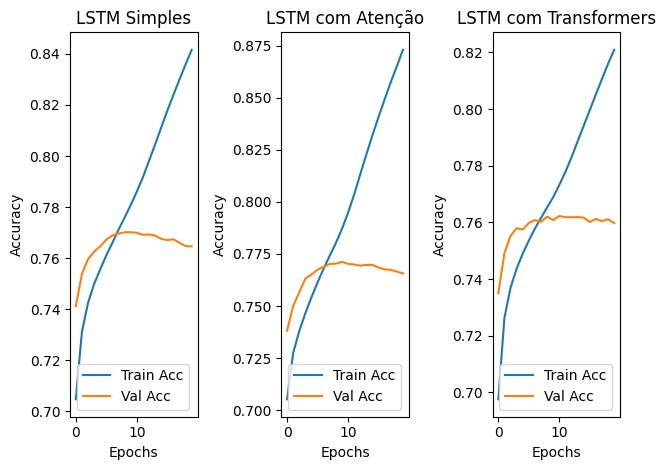

In [ ]:
# Mostrar os gráficos

plt.ion()   # Reativa o modo interativo
plt.tight_layout()  # Ajusta para não sobrepor elementos
plt.show()

In [ ]:
# Comparação entre as traduções das frases

print(f"Modelo Encoder-Decoder LSTM Simples:")
print(f"Frase Pequena:\nFR: {frase_p}\nPT: {traducoes[0][0]}")
print(f"Frase Grande:\nFR: {frase_g}\nPT: {traducoes[0][1]}")

print(f"Modelo Encoder-Decoder LSTM com Atenção:")
print(f"Frase Pequena:\nFR: {frase_p}\nPT: {traducoes[1][0]}")
print(f"Frase Grande:\nFR: {frase_g}\nPT: {traducoes[1][1]}")

print(f"Modelo Encoder-Decoder LSTM com Transformadores:")
print(f"Frase Pequena:\nFR: {frase_p}\nPT: {traducoes[2][0]}")
print(f"Frase Grande:\nFR: {frase_g}\nPT: {traducoes[2][1]}")


Modelo Encoder-Decoder LSTM Simples:
Frase Pequena:
FR: j'adore voir des chats
PT: também ecologias .                                              
Frase Grande:
FR: au ver qui a rongé en premier la chair froide de mon cadavre
PT: à procura de informação , a empresa ,                                         
Modelo Encoder-Decoder LSTM com Atenção:
Frase Pequena:
FR: j'adore voir des chats
PT: os resultados                                               
Frase Grande:
FR: au ver qui a rongé en premier la chair froide de mon cadavre
PT: do na escola de harold ter sido o suficiente para o seu próprio tratamento .                                  
Modelo Encoder-Decoder LSTM com Transformadores:
Frase Pequena:
FR: j'adore voir des chats
PT: muito rapidamente .                                              
Frase Grande:
FR: au ver qui a rongé en premier la chair froide de mon cadavre
PT: que o que a maioria dos ceo 's argumentaria que a é a primeira vez .                                 




---


# Conclusão

Após treinamento e teste dos modelos com 20 épocas, é perceptível que, para o conjunto de dados fornecido, os três modelos obtiveram resultados muito semelhantes na acurácia (por volta de 76%). Confere-se, nos gráficos de treino, como a relação de acurácia de treino e de acurácia de validação permanece muito parecida em todos os modelos.

Nesse sentido, o que se saiu levemente melhor que os outros foi o modelo de LSTM com Atenção, com 76,57% de acurácia. Entretanto, a baixa diferença em relação aos resultados dos outros modelos não nos permite tirar conclusões sobre o motivo disso, uma vez que essa porcentagem flutuaria facilmente com um número maior de épocas ou de dados.

Além disso, vale perceber que nenhum dos três modelos foi capaz de traduzir as frases dadas, nem a grande e nem a pequena. Isso pode se dar a várias razões, como o número baixo de épocas e a baixa quantidade de dados de treino. Isso demonstra a alta quantidade de esforço computacional e de dados necessária para rodar um modelo Encoder Decoder com LSTM.